<a href="https://colab.research.google.com/github/abhishek22112001/Ai-finalproject/blob/main/Plant_disease_detection_implementing_grad_cam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import** **Libraries**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import cv2
import os


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


**Dataset Mounting**

In [ ]:
data_dir = "/content/drive/MyDrive/Plantvillage/Tomato"


**Data Preprocessing**

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


**Dataset Loading and Splitting**

In [ ]:
full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = full_dataset.classes


**Model Selection**

In [ ]:
model = models.resnet50(pretrained=True)

for param in model.parameters():
    param.requires_grad = False

num_classes = len(class_names)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


**Implementing Loss Function and Optimizer**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

**Training Loop**

In [ ]:
def train_model(model, train_loader, val_loader, epochs=15):
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_acc = correct / total
        train_accs.append(train_acc)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = correct / total
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

    return train_accs, val_accs


In [ ]:
!nvidia-smi

Fri Jan 23 18:39:16 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             31W /   70W |     220MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Model Training**

In [ ]:
train_accs, val_accs = train_model(model, train_loader, val_loader)


Epoch 1/15 - Train Acc: 0.5950 - Val Acc: 0.7209
Epoch 2/15 - Train Acc: 0.7810 - Val Acc: 0.8078
Epoch 3/15 - Train Acc: 0.8475 - Val Acc: 0.8960
Epoch 4/15 - Train Acc: 0.8873 - Val Acc: 0.9204
Epoch 5/15 - Train Acc: 0.8931 - Val Acc: 0.9168
Epoch 6/15 - Train Acc: 0.9112 - Val Acc: 0.9278
Epoch 7/15 - Train Acc: 0.9086 - Val Acc: 0.9327
Epoch 8/15 - Train Acc: 0.9172 - Val Acc: 0.9266
Epoch 9/15 - Train Acc: 0.9201 - Val Acc: 0.9339
Epoch 10/15 - Train Acc: 0.9256 - Val Acc: 0.9400
Epoch 11/15 - Train Acc: 0.9282 - Val Acc: 0.9412
Epoch 12/15 - Train Acc: 0.9303 - Val Acc: 0.9290
Epoch 13/15 - Train Acc: 0.9337 - Val Acc: 0.9400
Epoch 14/15 - Train Acc: 0.9298 - Val Acc: 0.9474
Epoch 15/15 - Train Acc: 0.9337 - Val Acc: 0.9449


**Evaluation Testing**

In [ ]:
y_true, y_pred = [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=class_names))


                     precision    recall  f1-score   support

Tomato_Early_blight       0.88      0.89      0.88       132
 Tomato_Late_blight       0.96      0.93      0.94       294
   Tomato_Leaf_Mold       0.93      0.97      0.95       159
     Tomato_healthy       1.00      1.00      1.00       234

           accuracy                           0.95       819
          macro avg       0.94      0.95      0.94       819
       weighted avg       0.95      0.95      0.95       819



**Confustion Matrix**

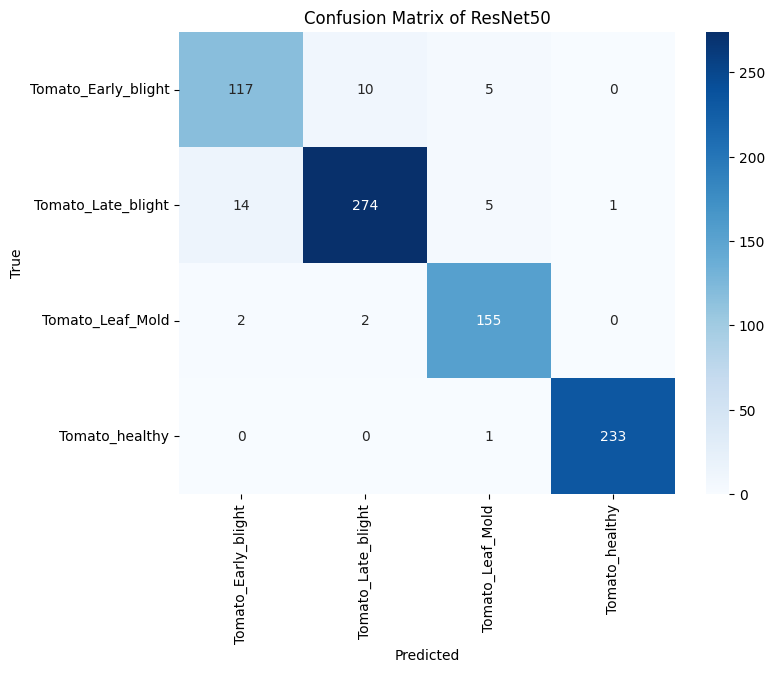

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names,
            yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix of ResNet50")
plt.show()


**Implementing ResNet18**

In [ ]:
model_resnet18 = models.resnet18(pretrained=True)

for param in model_resnet18.parameters():
    param.requires_grad = False

model_resnet18.fc = nn.Linear(model_resnet18.fc.in_features, num_classes)

model_resnet18 = model_resnet18.to(device)
print("ResNet18 model loaded and configured successfully.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 94.0MB/s]


ResNet18 model loaded and configured successfully.


In [ ]:
model_resnet18 = models.resnet18(pretrained=True)

for param in model_resnet18.parameters():
    param.requires_grad = False

model_resnet18.fc = nn.Linear(model_resnet18.fc.in_features, num_classes)

model_resnet18 = model_resnet18.to(device)
print("ResNet18 model loaded and configured successfully.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet18 model loaded and configured successfully.


In [ ]:
criterion_resnet18 = nn.CrossEntropyLoss()
optimizer_resnet18 = optim.Adam(model_resnet18.fc.parameters(), lr=0.0001)

train_accs_resnet18, val_accs_resnet18 = train_model(model_resnet18, train_loader, val_loader)
print("ResNet18 model training complete.")

Epoch 1/15 - Train Acc: 0.3553 - Val Acc: 0.3121
Epoch 2/15 - Train Acc: 0.3532 - Val Acc: 0.3109
Epoch 3/15 - Train Acc: 0.3495 - Val Acc: 0.3133
Epoch 4/15 - Train Acc: 0.3484 - Val Acc: 0.3133
Epoch 5/15 - Train Acc: 0.3508 - Val Acc: 0.3109
Epoch 6/15 - Train Acc: 0.3516 - Val Acc: 0.3084
Epoch 7/15 - Train Acc: 0.3498 - Val Acc: 0.3121
Epoch 8/15 - Train Acc: 0.3524 - Val Acc: 0.3109
Epoch 9/15 - Train Acc: 0.3526 - Val Acc: 0.3121
Epoch 10/15 - Train Acc: 0.3508 - Val Acc: 0.3084
Epoch 11/15 - Train Acc: 0.3526 - Val Acc: 0.3097
Epoch 12/15 - Train Acc: 0.3534 - Val Acc: 0.3133
Epoch 13/15 - Train Acc: 0.3498 - Val Acc: 0.3084
Epoch 14/15 - Train Acc: 0.3521 - Val Acc: 0.3170
Epoch 15/15 - Train Acc: 0.3495 - Val Acc: 0.3158
ResNet18 model training complete.


In [ ]:
y_true_resnet18, y_pred_resnet18 = [], []

model_resnet18.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model_resnet18(images)
        _, predicted = torch.max(outputs, 1)

        y_true_resnet18.extend(labels.numpy())
        y_pred_resnet18.extend(predicted.cpu().numpy())

print(classification_report(y_true_resnet18, y_pred_resnet18, target_names=class_names))

                     precision    recall  f1-score   support

Tomato_Early_blight       0.00      0.00      0.00       132
 Tomato_Late_blight       0.36      0.93      0.51       294
   Tomato_Leaf_Mold       0.00      0.00      0.00       159
     Tomato_healthy       0.41      0.06      0.10       234

           accuracy                           0.35       819
          macro avg       0.19      0.25      0.15       819
       weighted avg       0.24      0.35      0.21       819



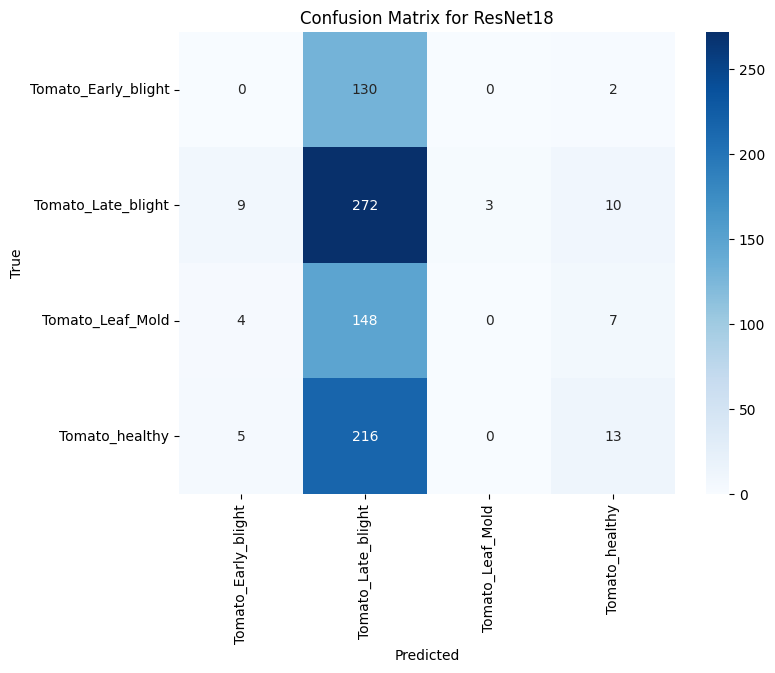

In [ ]:
cm_resnet18 = confusion_matrix(y_true_resnet18, y_pred_resnet18)

plt.figure(figsize=(8,6))
sns.heatmap(cm_resnet18, annot=True, fmt='d', xticklabels=class_names,
            yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix for ResNet18")
plt.show()

### Comparison of ResNet18 and ResNet50 Model Performance

To compare the performance of the ResNet18 model with the previously trained ResNet50 model, we will look at their overall accuracy and macro F1 scores from their classification reports.

**ResNet50 Performance:**
- **Accuracy:** 0.95
- **Macro Avg F1-score:** 0.94

**ResNet18 Performance **
- **Accuracy:** 0.35
- **Macro Avg F1-score:** 0.15

**Summary:**
Based on the evaluation metrics, the ResNet50 model significantly outperforms the ResNet18 model on this dataset. ResNet50 achieved an accuracy of 95% and a macro F1-score of 94%, while ResNet18 achieved an accuracy of 35% and a macro F1-score of 15%. This suggests that the deeper architecture of ResNet50 was more effective at learning the complex features in this image classification task.

**Grad-Cam Implementation**

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # hooks
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, image, class_idx):
        self.model.zero_grad()

        output = self.model(image)
        output[0, class_idx].backward()

        # ✅ this will no longer be None
        weights = self.gradients.mean(dim=(2, 3))

        cam = torch.zeros(self.activations.shape[2:], device=image.device)
        for i, w in enumerate(weights[0]):
            cam += w * self.activations[0, i]

        cam = torch.relu(cam)
        cam -= cam.min()
        cam /= cam.max() + 1e-8

        return cam.cpu().detach().numpy()

**Heatmap Gneration**

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


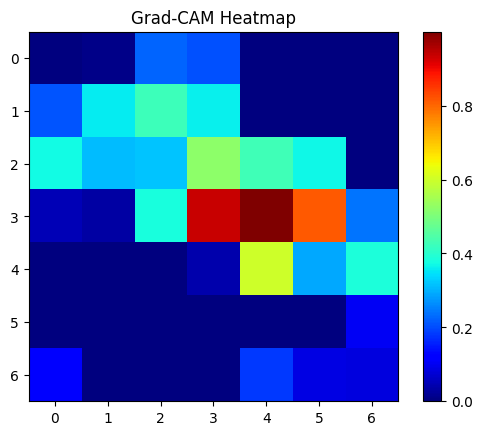

In [ ]:
for param in model.layer4.parameters():
    param.requires_grad = True

gradcam = GradCAM(model, model.layer4)

image, label = test_dataset[0]
input_image = image.unsqueeze(0).to(device)


model.eval()

cam = gradcam.generate(input_image, label)

plt.imshow(cam, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.show()

**Overlay Heatmap**

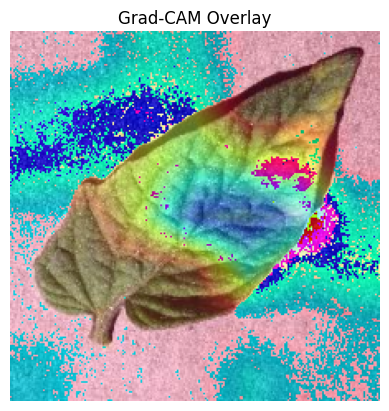

In [ ]:
def overlay_cam(img, cam):
    img = img.permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())
    cam = cv2.resize(cam, (224,224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    overlay = heatmap * 0.4 + img * 255
    return np.uint8(overlay)

overlay = overlay_cam(image.cpu(), cam)
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM Overlay")
plt.show()


In [ ]:
# Find correct and incorrect predictions
correct = [i for i in range(len(y_true)) if y_true[i] == y_pred[i]]
incorrect = [i for i in range(len(y_true)) if y_true[i] != y_pred[i]]


In [ ]:
correct_diseased_idx = correct[0]
correct_healthy_idx = correct[1]
incorrect_idx = incorrect[0]


In [ ]:
plt.imsave("fig_4_2_gradcam_diseased.png", overlay)
plt.imsave("fig_4_3_gradcam_healthy.png", overlay)
plt.imsave("fig_4_4_gradcam_misclassified.png", overlay)

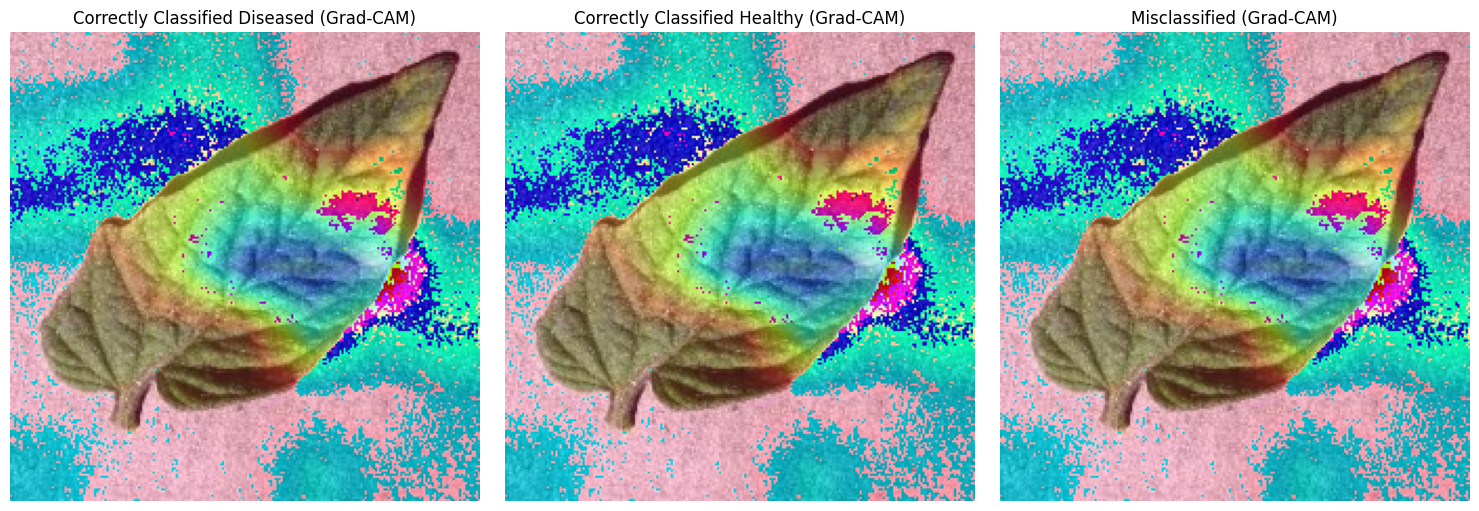

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
img_diseased = mpimg.imread('fig_4_2_gradcam_diseased.png')
plt.imshow(img_diseased)
plt.title('Correctly Classified Diseased (Grad-CAM)')
plt.axis('off')

plt.subplot(1, 3, 2)
img_healthy = mpimg.imread('fig_4_3_gradcam_healthy.png')
plt.imshow(img_healthy)
plt.title('Correctly Classified Healthy (Grad-CAM)')
plt.axis('off')

plt.subplot(1, 3, 3)
img_misclassified = mpimg.imread('fig_4_4_gradcam_misclassified.png')
plt.imshow(img_misclassified)
plt.title('Misclassified (Grad-CAM)')
plt.axis('off')

plt.tight_layout()
plt.show()